# Seoul Real Estate Market Overview (2018–2024)

## Objective
Exploratory Data Analysis (EDA) of Seoul's real estate market to understand overall price trends, transaction volumes, and year-over-year growth rates from 2018 to 2024.

## Preprocessing Policy — Why Two Separate Notebooks?
This notebook **keeps the raw data as-is (no outlier removal)**.
> When analyzing overall market trends (annual price trajectory, transaction volume),
> removing outliers would distort real market shocks (e.g., the 2021–2022 surge period).
> Therefore, we retain extreme values to capture the full market picture.
>
> ※ For investor-type analysis (Z-score comparison), see the companion notebook
>    `Seoul_Real_Estate_Investment_Analysis.ipynb`, which applies IQR-based outlier removal.

## Data Structure
Place annual CSV files inside a `data/` folder at the project root:
```
project/
├── data/
│   ├── 2018.csv ~ 2024.csv
├── Seoul_Real_Estate_Market_Overview.ipynb
└── Seoul_Real_Estate_Investment_Analysis.ipynb
```

## Key Terms
| Korean Term | English Meaning |
|---|---|
| 물건금액(만원) | Transaction price (unit: 10,000 KRW) |
| 평당가격 | Price per pyeong (1 pyeong ≈ 3.3 m²) |
| 자치구명 | District (gu) name |
| 건물용도 | Building type |
| 접수연도 | Registration year |


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Font settings for Korean characters in district/building names
# (Data labels remain in Korean as they are proper nouns from the source data)
import platform
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# ── Load Data ────────────────────────────────────────────────────────
# Uses relative paths → place CSV files in the data/ folder
data_2018 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2018.csv', encoding="euc-kr",low_memory = False)
data_2019 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2019.csv', encoding="euc-kr",low_memory = False)
data_2020 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2020.csv', encoding="euc-kr",low_memory = False)
data_2021 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2021.csv', encoding="euc-kr",low_memory = False)
data_2022 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2022.csv', encoding="euc-kr",low_memory = False) 
data_2023 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2023.csv', encoding="euc-kr",low_memory = False)
data_2024 = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/서울 부동산 project 1/seoul_real_estate_dataset/2024.csv', encoding="euc-kr",low_memory = False)

In [3]:
# Merge All Years
# join="inner": use only columns that exist across ALL years
dfs = [data_2018, data_2019, data_2020, data_2021, data_2022, data_2023, data_2024]
df_all = pd.concat(dfs, axis=0, ignore_index=True, join="inner")
print("Combined dataset shape:", df_all.shape)

Combined dataset shape: (833614, 21)


In [4]:
# Rename Columns to English
# Source data has Korean column names; we rename for clarity
col_map = {
    "물건금액(만원)": "price_10k_krw",
    "건물면적(㎡)": "area_sqm",
    "자치구명": "district",
    "건물용도": "building_type",
    "접수연도": "year",
    "건축년도": "year_built",
    "취소일": "cancellation_date",
    "계약일": "contract_date",
}
df_all.rename(columns={k: v for k, v in col_map.items() if k in df_all.columns}, inplace=True)
print("Columns after renaming:")
print(df_all.columns.tolist())

Columns after renaming:
['year', '자치구코드', 'district', '법정동코드', '법정동명', '지번구분', '지번구분명', '본번', '부번', '건물명', 'contract_date', 'price_10k_krw', 'area_sqm', '토지면적(㎡)', '층', '권리구분', 'cancellation_date', 'year_built', 'building_type', '신고구분', '신고한 개업공인중개사 시군구명']


In [ ]:
# Remove Cancelled Transactions
# Only keep completed (non-cancelled) transactions
df_all = df_all[df_all["cancellation_date"].isna()]
print("After removing cancellations:", df_all.shape)

After removing cancellations: (808073, 21)


In [6]:
# Clean Year Built
# Remove impossible values (before 1900 or in the future)
df_all = df_all.copy()
df_all["year_built"] = pd.to_numeric(df_all["year_built"], errors="coerce")
current_year = pd.Timestamp.today().year
df_all = df_all[(df_all["year_built"] >= 1900) & (df_all["year_built"] <= current_year)]
print("After cleaning year_built:", df_all.shape)

# NOTE: This notebook does NOT remove price outliers.
# Extreme prices (e.g., the 2021–2022 surge) are meaningful market signals
# and should be preserved for trend analysis.

After cleaning year_built: (797441, 21)


In [7]:
# Derive Key Features
# Convert area: sqm → pyeong (1 pyeong = 3.3 sqm)
df_all["area_sqm"] = pd.to_numeric(df_all["area_sqm"], errors="coerce")
df_all["area_pyeong"] = df_all["area_sqm"] / 3.3

# Price per pyeong — enables fair comparison across different unit sizes
df_all["price_per_pyeong"] = df_all["price_10k_krw"] / df_all["area_pyeong"]

# Average price per pyeong by year
avg_py_year = df_all.groupby("year")["price_per_pyeong"].mean().reset_index().round(2)
print(avg_py_year)

   year  price_per_pyeong
0  2018           2371.04
1  2019           2793.40
2  2020           2923.07
3  2021           3176.23
4  2022           3115.02
5  2023           3726.05
6  2024           4126.40


## EDA — Exploratory Data Analysis
Basic data structure and distribution checks after preprocessing.

In [8]:
# EDA: Basic Data Inspection
print("=" * 55)
print("Dataset Overview")
print("=" * 55)
print(f"Total rows : {len(df_all):,}")
print(f"Total cols : {len(df_all.columns)}")
print()

# Missing value rate (only columns with missing values)
null_rate = (df_all.isnull().sum() / len(df_all) * 100).round(2)
null_df = null_rate[null_rate > 0].sort_values(ascending=False)
print("Missing value rate (columns with gaps only):")
print(null_df.to_string())
print()

# Summary statistics for key numeric columns
print("Descriptive statistics for key columns:")
print(df_all[["price_10k_krw", "area_sqm", "price_per_pyeong"]].describe().round(1).to_string())

Dataset Overview
Total rows : 797,441
Total cols : 23

Missing value rate (columns with gaps only):
권리구분                 100.00
cancellation_date    100.00
신고한 개업공인중개사 시군구명      78.40
신고구분                  73.51
토지면적(㎡)               20.27
지번구분                   6.81
지번구분명                  6.81
본번                     6.81
부번                     6.81
건물명                    6.81
층                      6.80

Descriptive statistics for key columns:
       price_10k_krw  area_sqm  price_per_pyeong
count       797441.0  797441.0          797441.0
mean         63555.8      69.9            3021.9
std          71607.0      64.9            1918.4
min           1700.0       5.1              78.8
25%          24500.0      38.9            1770.8
50%          41800.0      59.4            2546.8
75%          79120.0      84.8            3676.4
max       11087780.0    3619.8           32535.2


/var/folders/2m/_bqynwn904ndlfmk8kdlnn6w0000gn/T/ipykernel_88819/3775737444.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, labels=years_list, patch_artist=True,


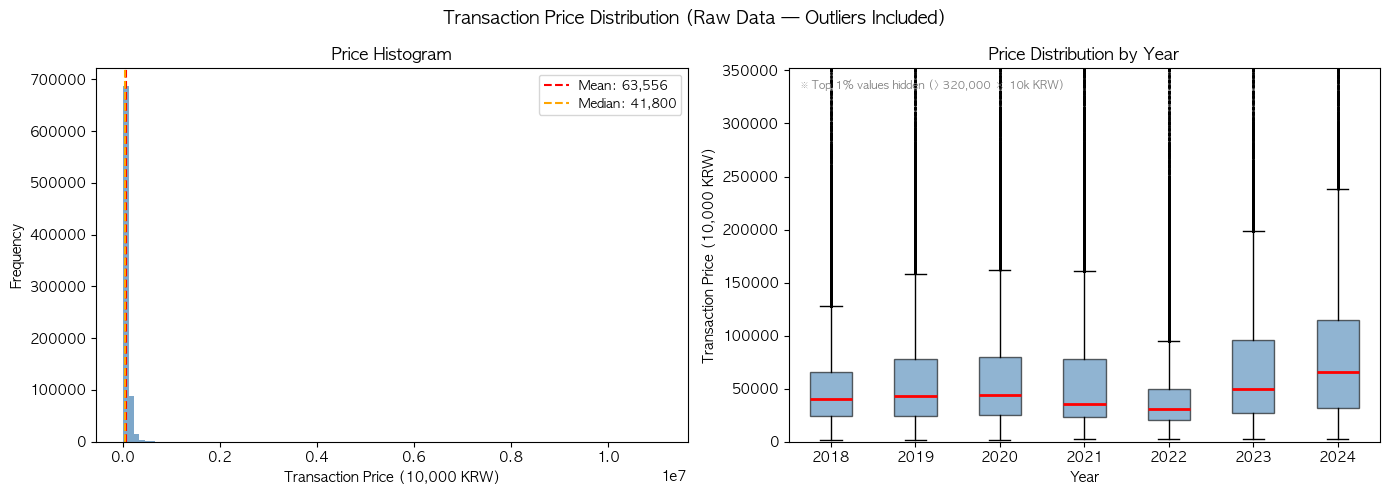

In [9]:
# EDA: Transaction Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Transaction Price Distribution (Raw Data — Outliers Included)",
             fontsize=13, fontweight="bold")

# Histogram
ax = axes[0]
ax.hist(df_all["price_10k_krw"].dropna(), bins=100,
        color="steelblue", alpha=0.7, edgecolor="none")
ax.set_title("Price Histogram")
ax.set_xlabel("Transaction Price (10,000 KRW)")
ax.set_ylabel("Frequency")
ax.axvline(df_all["price_10k_krw"].mean(), color="red", linestyle="--", linewidth=1.5,
           label=f"Mean: {df_all['price_10k_krw'].mean():,.0f}")
ax.axvline(df_all["price_10k_krw"].median(), color="orange", linestyle="--", linewidth=1.5,
           label=f"Median: {df_all['price_10k_krw'].median():,.0f}")
ax.legend(fontsize=9)

# Boxplot by year
ax = axes[1]
years_list = sorted(df_all["year"].unique())
data_by_year = [df_all[df_all["year"] == y]["price_10k_krw"].dropna() for y in years_list]
bp = ax.boxplot(data_by_year, labels=years_list, patch_artist=True,
                medianprops=dict(color="red", linewidth=2),
                flierprops=dict(marker=".", markersize=2, alpha=0.3))
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)
ax.set_title("Price Distribution by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Transaction Price (10,000 KRW)")
ax.tick_params(axis="x", rotation=0)

# Cap y-axis at 99th percentile for readability
p99 = df_all["price_10k_krw"].quantile(0.99)
ax.set_ylim(0, p99 * 1.1)
ax.text(0.02, 0.97,
        f"※ Top 1% values hidden (> {p99:,.0f} × 10k KRW)",
        transform=ax.transAxes, fontsize=8, color="gray", va="top")

plt.tight_layout()
plt.show()

In [10]:
# EDA: Building Type Distribution
print("Building type distribution:")
print(df_all["building_type"].value_counts().to_string())
print()

# Average transaction price by building type
bldg_price = (
    df_all.groupby("building_type")["price_10k_krw"]
    .agg(["mean", "count"]).round(1)
    .sort_values("mean", ascending=False)
)
bldg_price.columns = ["Avg Price (10k KRW)", "Transaction Count"]
print("Average transaction price by building type:")
print(bldg_price.to_string())

Building type distribution:
building_type
아파트      377445
연립다세대    282403
오피스텔      83341
단독다가구     54252

Average transaction price by building type:
               Avg Price (10k KRW)  Transaction Count
building_type                                        
단독다가구                     125840.6              54252
아파트                        87887.4             377445
연립다세대                      30100.2             282403
오피스텔                       26179.6              83341


## Annual Market Trend Analysis

In [11]:
# Compute Annual Summary Statistics

# Annual average transaction price
year_price = (
    df_all.groupby("year")["price_10k_krw"].mean()
    .reset_index().sort_values("year")
)

# Annual average price per pyeong
year_py = (
    df_all.groupby("year")["price_per_pyeong"].mean()
    .reset_index().sort_values("year")
)

# Annual transaction volume
year_volume = (
    df_all.groupby("year").size()
    .reset_index(name="volume").sort_values("year")
)

# Year-over-year price growth rate (%) using pct_change()
year_py_growth = year_py.copy()
year_py_growth["growth_rate_pct"] = year_py_growth["price_per_pyeong"].pct_change() * 100

# Merge into one summary table
year_summary = (
    year_price[["year", "price_10k_krw"]]
    .merge(year_py[["year", "price_per_pyeong"]], on="year")
    .merge(year_volume, on="year")
    .merge(year_py_growth[["year", "growth_rate_pct"]], on="year")
)
print(year_summary)

   year  price_10k_krw  price_per_pyeong  volume  growth_rate_pct
0  2018   54441.506166       2371.036046  163733              NaN
1  2019   61659.764716       2793.398491  128428        17.813413
2  2020   62344.669249       2923.068353  174131         4.642011
3  2021   62772.538443       3176.232607  130922         8.660908
4  2022   54627.634961       3115.018766   61399        -1.927247
5  2023   75598.974759       3726.045659   65371        19.615512
6  2024   88197.941626       4126.399783   73457        10.744746


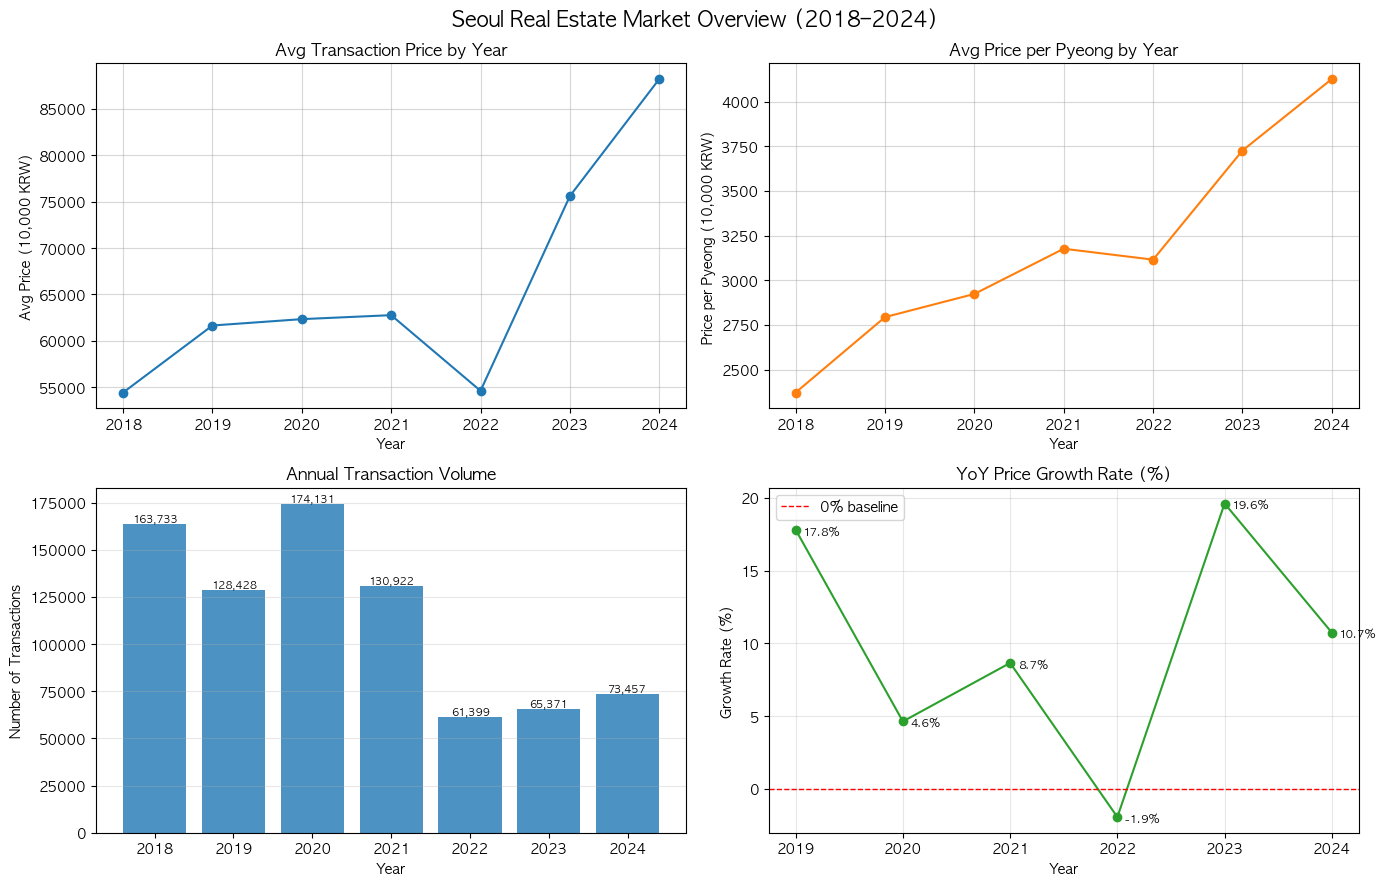

In [12]:
# Visualization: Seoul Market Overview (4-in-1)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Seoul Real Estate Market Overview (2018–2024)",
             fontsize=15, fontweight="bold")

# 1. Average transaction price by year
ax = axes[0, 0]
ax.plot(year_summary["year"], year_summary["price_10k_krw"],
        marker="o", linestyle="-")
ax.set_title("Avg Transaction Price by Year", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Avg Price (10,000 KRW)")
ax.grid(True, alpha=0.5)
ax.tick_params(axis="x", rotation=0)

# 2. Average price per pyeong by year
ax = axes[0, 1]
ax.plot(year_summary["year"], year_summary["price_per_pyeong"],
        marker="o", linestyle="-", color="tab:orange")
ax.set_title("Avg Price per Pyeong by Year", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Price per Pyeong (10,000 KRW)")
ax.grid(True, alpha=0.5)

# 3. Annual transaction volume
ax = axes[1, 0]
ax.bar(year_summary["year"], year_summary["volume"], alpha=0.8)
ax.set_title("Annual Transaction Volume", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Transactions")
for i, v in enumerate(year_summary["volume"]):
    ax.text(year_summary["year"].iloc[i], v, f"{v:,}",
            ha="center", va="bottom", fontsize=7.5)
ax.grid(axis="y", alpha=0.3)

# 4. YoY price growth rate (%)
ax = axes[1, 1]
ax.plot(year_summary["year"], year_summary["growth_rate_pct"],
        marker="o", linestyle="-", color="tab:green")
ax.axhline(0, color="red", linestyle="--", linewidth=1, label="0% baseline")
ax.set_title("YoY Price Growth Rate (%)", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Growth Rate (%)")
ax.grid(True, alpha=0.3)
ax.legend()
for i, v in enumerate(year_summary["growth_rate_pct"]):
    if pd.notna(v):
        ax.text(year_summary["year"].iloc[i] + 0.07, v - 0.5,
                f"{v:.1f}%", ha="left", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()